In [ ]:
!pip install librosa soundfile ruptures

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import librosa
import soundfile as sf
import numpy as np
import ruptures as rpt
import os

# Load audio
audio_file = "/content/drive/MyDrive/colab_datas/isp_comm/bird_sound_shorts_1.m4a"

y, sr = librosa.load(audio_file, sr=16000)

# MFCC features
mfcc = librosa.feature.mfcc(
    y=y,
    sr=sr,
    n_mfcc=20,
    hop_length=160,
    n_fft=400
).T

# Change point detection
algo = rpt.Pelt(model="rbf").fit(mfcc)
breaks = algo.predict(pen=8)

hop = 160

os.makedirs("segments", exist_ok=True)

start = 0

for i, end_frame in enumerate(breaks):
    end = end_frame * hop

    if end - start < sr * 0.15:
        continue

    segment = y[start:end]

    sf.write(
        f"segments/segment_{i:04d}.wav",
        segment,
        sr
    )

    start = end

print("Done")

In [4]:
import librosa
import numpy as np
import ruptures as rpt
from IPython.display import Audio, display, Markdown

#audio_file = "/content/input.wav"
audio_file = "/content/drive/MyDrive/colab_datas/isp_comm/bird_sound_shorts_1.m4a"

# Load audio
y, sr = librosa.load(audio_file, sr=16000)

# Extract MFCC features
mfcc = librosa.feature.mfcc(
    y=y,
    sr=sr,
    n_mfcc=20,
    hop_length=160,
    n_fft=400
).T

# Detect change points
algo = rpt.Pelt(model="rbf").fit(mfcc)
breaks = algo.predict(pen=8)

hop = 160
start = 0

print(f"Detected {len(breaks)} candidate segments\n")

for i, end_frame in enumerate(breaks):
    end = end_frame * hop

    # Skip segments shorter than 150 ms
    if end - start < int(sr * 0.15):
        continue

    segment = y[start:end]

    duration = len(segment) / sr

    display(Markdown(
        f"### Segment {i+1}\n"
        f"- Start: **{start/sr:.2f} s**\n"
        f"- End: **{end/sr:.2f} s**\n"
        f"- Duration: **{duration:.2f} s**"
    ))

    display(Audio(segment, rate=sr))

    start = end

/tmp/ipykernel_1198/3315664811.py:10: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_file, sr=16000)


Detected 11 candidate segments



### Segment 1
- Start: **0.00 s**
- End: **3.25 s**
- Duration: **3.25 s**

### Segment 2
- Start: **3.25 s**
- End: **4.35 s**
- Duration: **1.10 s**

### Segment 3
- Start: **4.35 s**
- End: **5.95 s**
- Duration: **1.60 s**

...

### Segment 7
- Start: **10.20 s**
- End: **11.20 s**
- Duration: **1.00 s**

### Segment 8
- Start: **11.20 s**
- End: **12.50 s**
- Duration: **1.30 s**

### Segment 9
- Start: **12.50 s**
- End: **13.45 s**
- Duration: **0.95 s**

### Segment 10
- Start: **13.45 s**
- End: **14.30 s**
- Duration: **0.85 s**

### Segment 11
- Start: **14.30 s**
- End: **15.77 s**
- Duration: **1.47 s**

DISPLAY

/tmp/ipykernel_1198/497986913.py:9: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_file, sr=None, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Sample Rate: 44100
Duration: 1.00 seconds
Samples: 44000


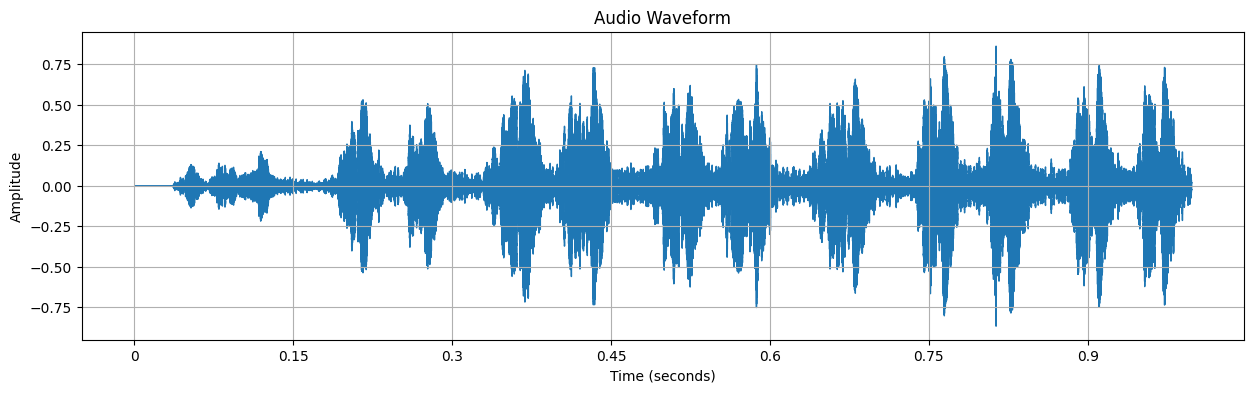

In [66]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

# Path to your audio
#audio_file = "/content/input.wav"

# Load audio
y, sr = librosa.load(audio_file, sr=None, mono=True)

def show_audio(y, sr):
  print(f"Sample Rate: {sr}")
  print(f"Duration: {len(y)/sr:.2f} seconds")
  print(f"Samples: {len(y)}")

  # Plot waveform
  plt.figure(figsize=(15,4))
  librosa.display.waveshow(y, sr=sr)
  plt.title("Audio Waveform")
  plt.xlabel("Time (seconds)")
  plt.ylabel("Amplitude")
  plt.grid(True)
  plt.show()


show_audio(y[:44000], sr)

/tmp/ipykernel_1198/2797671309.py:59: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_file, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


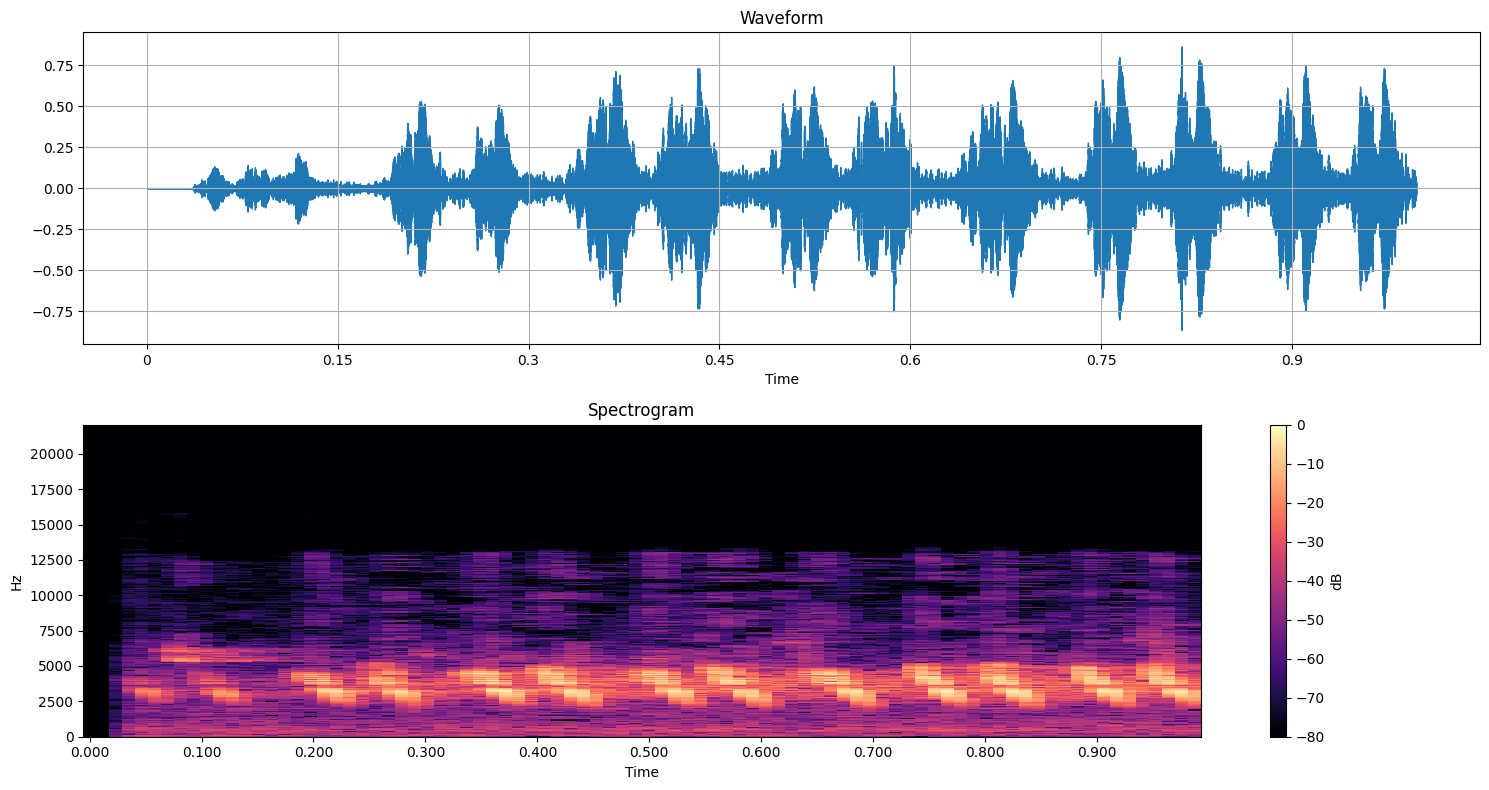

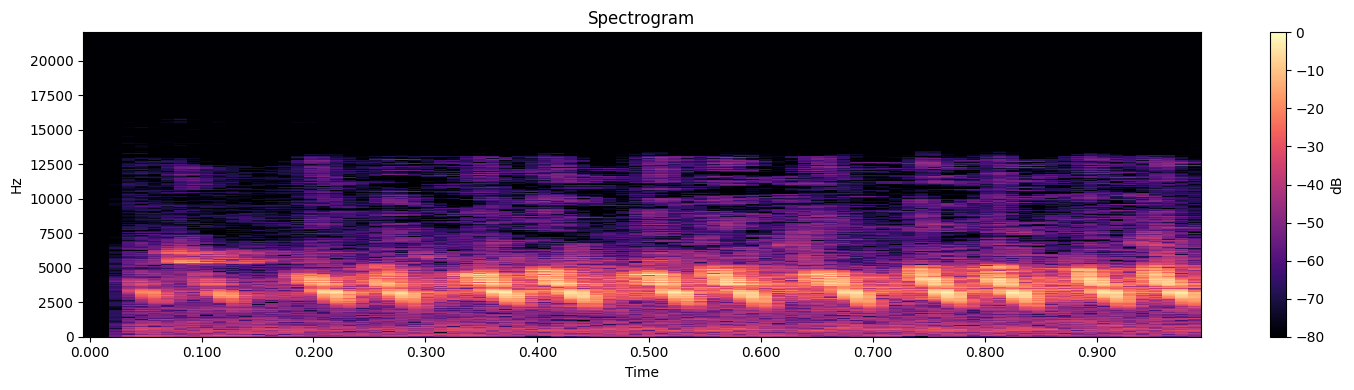

In [67]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

#audio_file = "/content/input.wav"

def show_audio_wave_and_spec(y, sr):
  plt.figure(figsize=(15,8))

  # Waveform
  plt.subplot(2,1,1)
  librosa.display.waveshow(y, sr=sr)
  plt.title("Waveform")
  plt.grid(True)

  # Spectrogram
  D = librosa.amplitude_to_db(
      np.abs(librosa.stft(y)),
      ref=np.max
  )

  plt.subplot(2,1,2)
  librosa.display.specshow(
      D,
      sr=sr,
      x_axis='time',
      y_axis='hz',
      cmap='magma'
  )
  plt.colorbar(label='dB')
  plt.title("Spectrogram")

  plt.tight_layout()
  plt.show()

def show_audio_spectro(y, sr):
  plt.figure(figsize=(15,4))

  # Spectrogram
  D = librosa.amplitude_to_db(
      np.abs(librosa.stft(y)),
      ref=np.max
  )

  librosa.display.specshow(
      D,
      sr=sr,
      x_axis='time',
      y_axis='hz',
      cmap='magma'
  )
  plt.colorbar(label='dB')
  plt.title("Spectrogram")

  plt.tight_layout()
  plt.show()

y, sr = librosa.load(audio_file, sr=None)
show_audio_wave_and_spec(y[0:44000],sr)
show_audio_spectro(y[0:44000],sr)



### BAND PASS FILTERS

| Source          |              Suggested Band |
| --------------- | --------------------------: |
| Human speech    |                 300–4000 Hz |
| Children        |                 250–6000 Hz |
| Birds           |               1000–10000 Hz |
| Dogs            |                 200–8000 Hz |
| Unknown species | 50 Hz to 0.45 × sample_rate |




In [58]:
# band pass filter

import numpy as np
from scipy.signal import butter, filtfilt

def bandpass_filter(signal,
                    sample_rate,
                    lowcut=300,
                    highcut=4000,
                    order=4):
    """
    Butterworth zero-phase band-pass filter.

    Parameters
    ----------
    signal : np.ndarray
        1D audio signal.
    sample_rate : int
        Sample rate in Hz.
    lowcut : float
        Low cutoff frequency (Hz).
    highcut : float
        High cutoff frequency (Hz).
    order : int
        Filter order.

    Returns
    -------
    np.ndarray
        Filtered signal.
    """

    signal = np.asarray(signal, dtype=np.float32)

    nyquist = sample_rate * 0.5

    low = lowcut / nyquist
    high = highcut / nyquist

    if low <= 0:
        low = 1e-6
    if high >= 1:
        high = 0.999999

    b, a = butter(order, [low, high], btype="band")

    return filtfilt(b, a, signal)

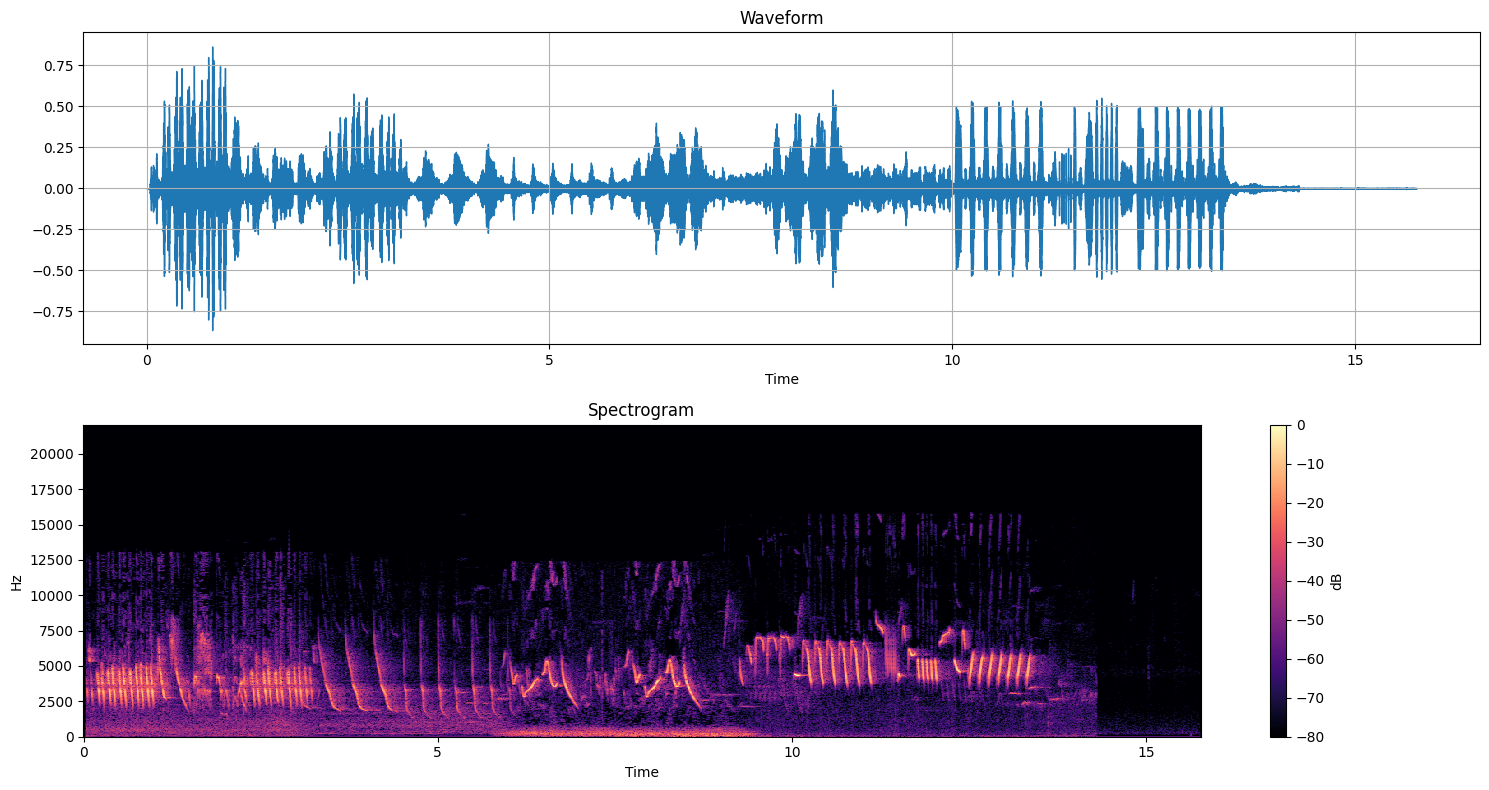

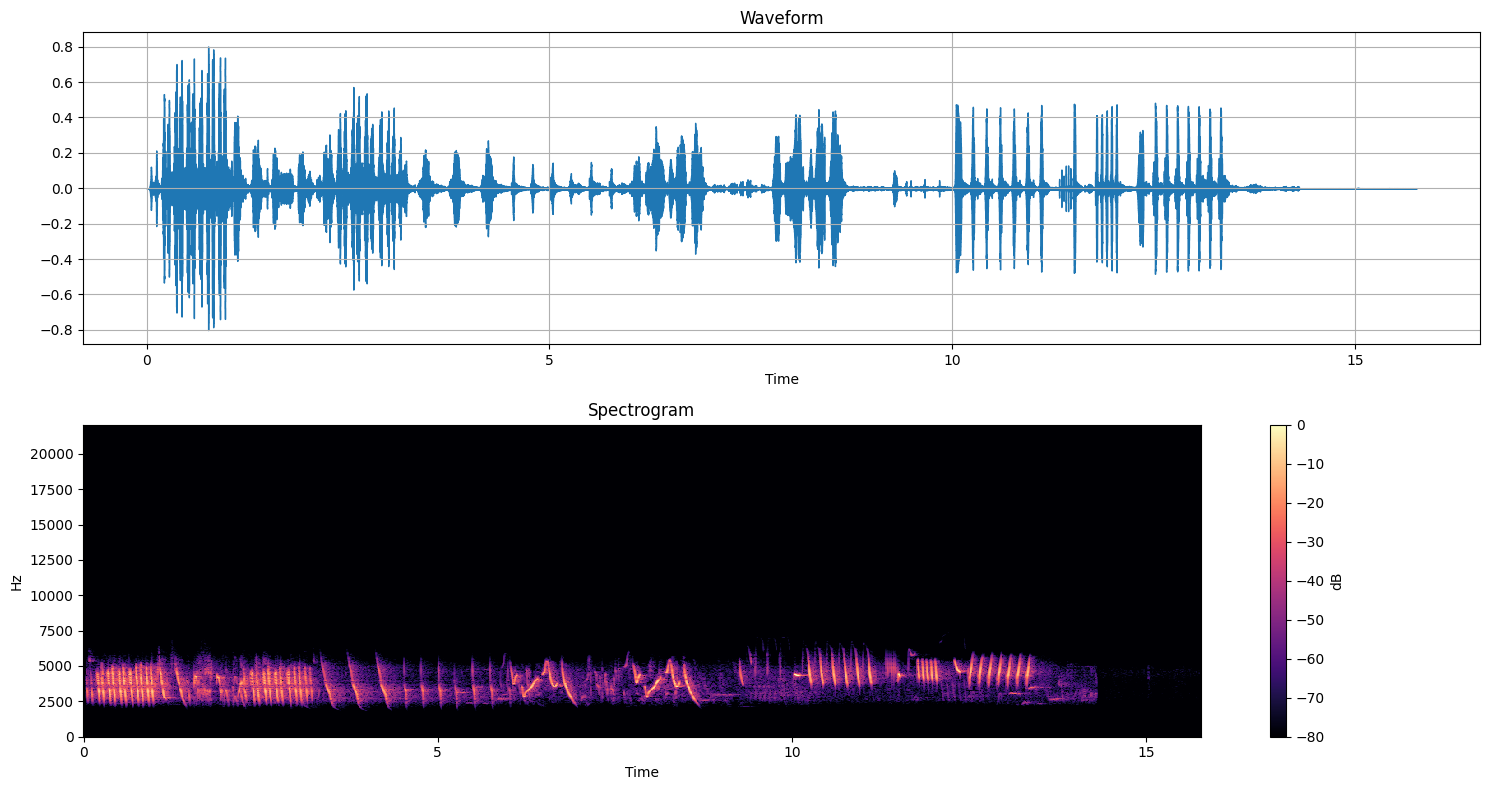

In [65]:
#band pass tests
filtered = bandpass_filter(
    y,
    sample_rate=sr,
    lowcut=2500,
    highcut=5000
)

show_audio_wave_and_spec(y,sr)
show_audio_wave_and_spec(filtered,sr)


ENERGY ACCUMULATION


Sample Rate: 44100
Duration: 1.41 seconds
Samples: 62000


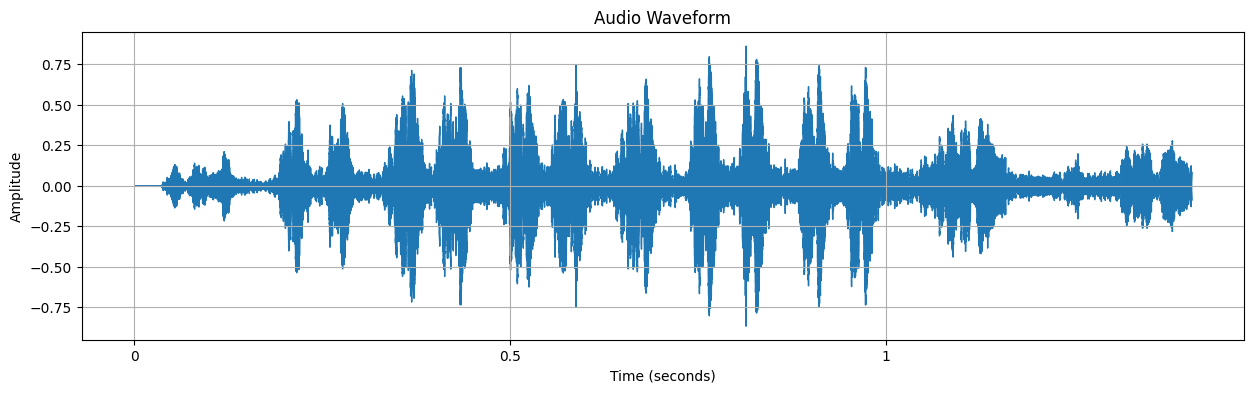

Sample Rate: 44100
Duration: 1.41 seconds
Samples: 62000


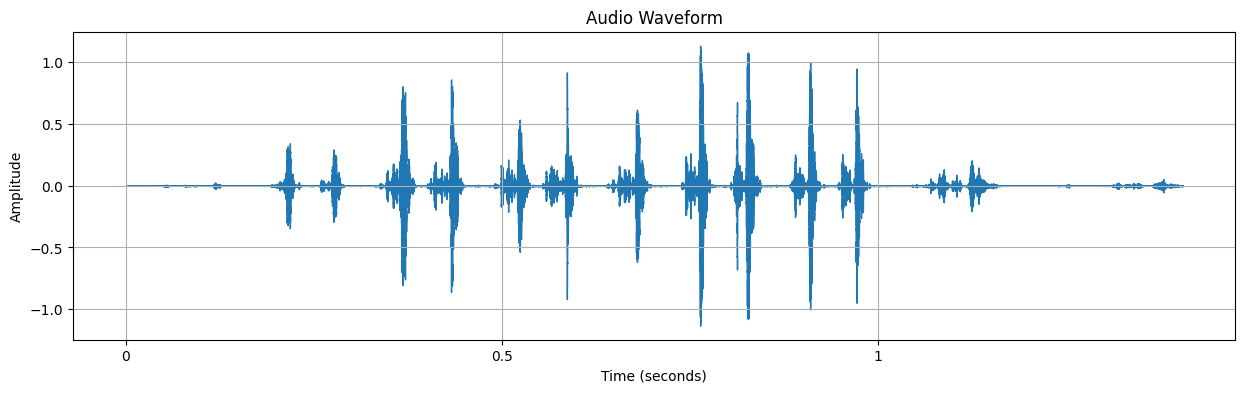

Sample Rate: 44100
Duration: 1.41 seconds
Samples: 62000


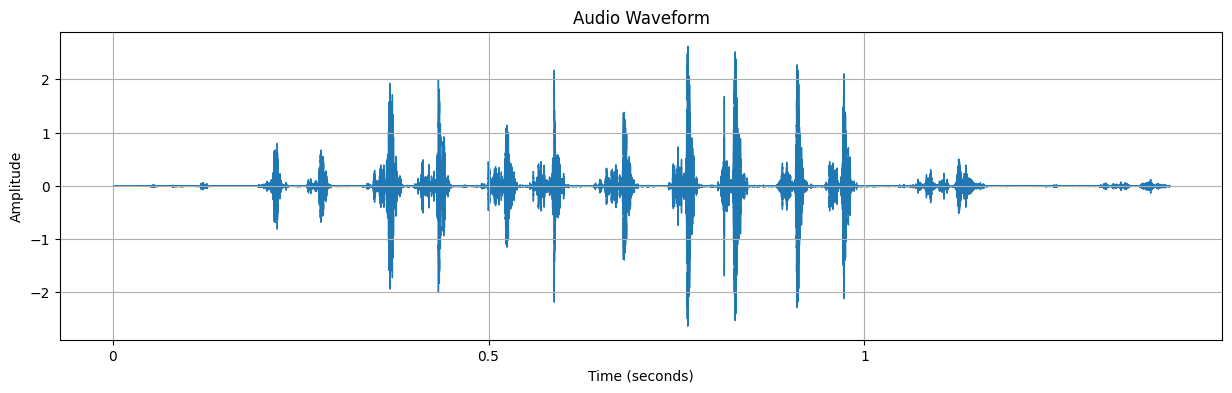

Sample Rate: 44100
Duration: 1.41 seconds
Samples: 62000


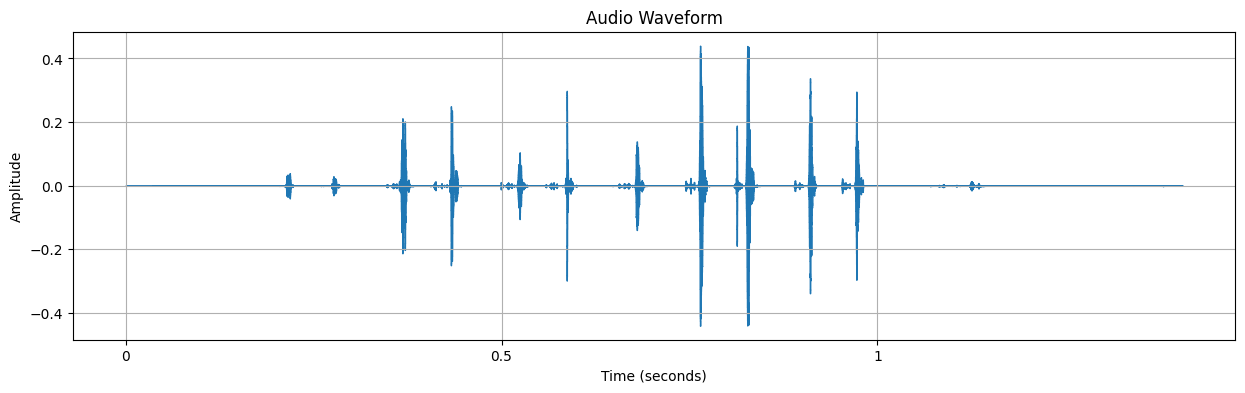

In [57]:
import numpy as np
import math

def accumulate_energy(signal, radius=5, decay=0.8, normalize=False):
    """
    Accumulate energy from nearby samples.

    Parameters
    ----------
    signal : np.ndarray
        1D input array.
    radius : int
        Number of neighbors on each side.
    decay : float
        Weight decay per distance.
        1.0 = equal weights
        0.8 = exponential decay
        0.0 = only current sample
    normalize : bool
        Divide by total weights.

    Returns
    -------
    np.ndarray
        Energy accumulated at each position.
    """
    signal = np.asarray(signal, dtype=np.float32)

    distances = np.arange(-radius, radius + 1)
    weights = decay ** np.abs(distances)

    #weights = np.log10(weights)

    if normalize:
        weights /= weights.sum()

    return np.convolve(signal, weights, mode="same")

def local_energy(signal, radius=5):
    signal = np.asarray(signal, dtype=np.float32)
    energy = signal ** 3
    kernel = np.ones(2 * radius + 1)
    return np.convolve(energy, kernel, mode="same")

import numpy as np

def gaussian_local_energy(signal, sigma=20, radius=None, normalize=True):
    """
    Gaussian-weighted local energy envelope.

    Parameters
    ----------
    signal : np.ndarray
        1D audio waveform.
    sigma : float
        Standard deviation of Gaussian (samples).
    radius : int or None
        Kernel radius. Default = 3*sigma.
    normalize : bool
        Normalize kernel to sum to 1.

    Returns
    -------
    np.ndarray
        Smoothed local energy envelope.
    """

    signal = np.asarray(signal, dtype=np.float32)

    # Instantaneous energy
    energy = signal ** 2

    if radius is None:
        radius = int(np.ceil(3 * sigma))

    x = np.arange(-radius, radius + 1)

    kernel = np.exp(-(x ** 2) / (2 * sigma ** 2))

    if normalize:
        kernel /= kernel.sum()

    envelope = np.convolve(energy, kernel, mode="same")

    return envelope

show_audio(y[0:62000],sr)

#energy = accumulate_energy(y[0:22000],radius=20, decay=0.5,  normalize=False);
energy = local_energy(y[0:62000],radius=5);
#print(energy)
show_audio(energy,sr)

acc_energy = accumulate_energy(energy,radius=50, decay=0.59,  normalize=False);
show_audio(acc_energy,sr)


gl_energy = gaussian_local_energy(energy,  sigma=5, radius=50);
show_audio(gl_energy,sr)